In [1]:
# 유전자 알고리즘 기반 로봇 경로 탐색 알고리즘 구현
# 논문: "유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길찾기 알고리즘"

import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time
from copy import deepcopy

# 랜덤 시드 설정
np.random.seed(42)
random.seed(42)

In [2]:
def create_map():
    """그림 2의 10x10 지도 생성"""
    # 10x10 빈 지도 생성 (0: 빈 공간, 1: 장애물)
    map_data = np.zeros((10, 10))
    
    # 그림 2의 장애물 위치 설정 (수정됨: 7행 0열 장애물 추가)
    obstacles = [(0, 2), (0, 3),(1, 2), (1, 3), (2, 2), (2, 3), (3, 2), (3, 3),
                 (1, 7), (1, 8), (1, 9),
                 (4, 5), (4, 6), (5, 5), (5, 6), (6, 5), (6, 6),
                 (7, 1), (7, 2), (8, 1), (8, 2),
                 (7, 8), (8, 8),
                 (9, 4), (9, 5)]
    
    for i, j in obstacles:
        map_data[i, j] = 1
    
    return map_data

def visualize_map(map_data, path=None, title="Map"):
    """지도와 경로 시각화"""
    plt.figure(figsize=(8, 8))
    plt.imshow(map_data, cmap='binary')
    
    # 격자 표시
    for i in range(map_data.shape[0] + 1):
        plt.axhline(i - 0.5, color='gray', linestyle='-', alpha=0.3)
        plt.axvline(i - 0.5, color='gray', linestyle='-', alpha=0.3)
    
    # 노드 번호 부여
    for i in range(map_data.shape[0]):
        for j in range(map_data.shape[1]):
            node_num = i * map_data.shape[1] + j + 1
            plt.text(j, i, f'{node_num}', ha='center', va='center', 
                     color='white' if map_data[i, j] == 1 else 'black')
    
    # 경로가 있으면 표시
    if path:
        path_coords = []
        for node in path:
            row = (node - 1) // map_data.shape[1]
            col = (node - 1) % map_data.shape[1]
            path_coords.append((col, row))
        
        # 경로 표시
        x_coords = [x for x, y in path_coords]
        y_coords = [y for x, y in path_coords]
        plt.plot(x_coords, y_coords, 'r-', linewidth=2)
        plt.plot(x_coords, y_coords, 'bo', markersize=8)
        
        # 시작점과 목표점 표시
        plt.plot(x_coords[0], y_coords[0], 'go', markersize=10)
        plt.plot(x_coords[-1], y_coords[-1], 'mo', markersize=10)
    
    plt.title(title)
    plt.grid(True)
    plt.xticks(range(map_data.shape[1]))
    plt.yticks(range(map_data.shape[0]))
    plt.show()

In [3]:
def node_to_coord(node_num, map_size=10):
    """노드 번호를 좌표로 변환"""
    row = (node_num - 1) // map_size
    col = (node_num - 1) % map_size
    return row, col

def coord_to_node(row, col, map_size=10):
    """좌표를 노드 번호로 변환"""
    return row * map_size + col + 1

def euclidean_distance(node1, node2, map_size=10):
    """두 노드 사이의 유클리드 거리 계산"""
    row1, col1 = node_to_coord(node1, map_size)
    row2, col2 = node_to_coord(node2, map_size)
    return np.sqrt((row1 - row2) ** 2 + (col1 - col2) ** 2)

def is_safe_edge(node1, node2, map_data, debug=False):
    """두 노드를 연결하는 간선이 안전한지 확인"""
    # 같은 노드라면 안전함
    if node1 == node2:
        return True
    
    row1, col1 = node_to_coord(node1)
    row2, col2 = node_to_coord(node2)
    
    # 노드 자체가 장애물인 경우
    if map_data[row1, col1] == 1 or map_data[row2, col2] == 1:
        if debug:
            print(f"노드 {node1} 또는 {node2}가 장애물입니다.")
        return False
    
    # 인접한 노드인 경우 바로 안전성 결정
    if abs(row1 - row2) <= 1 and abs(col1 - col2) <= 1:
        return True
    
    # 브레젠험 알고리즘으로 선 그리기
    steep = abs(col2 - col1) < abs(row2 - row1)
    if steep:
        col1, row1 = row1, col1
        col2, row2 = row2, col2
    
    if col1 > col2:
        col1, col2 = col2, col1
        row1, row2 = row2, row1
    
    dx = col2 - col1
    dy = abs(row2 - row1)
    error = dx // 2
    ystep = 1 if row1 < row2 else -1
    y = row1
    
    for x in range(col1, col2 + 1):
        coord = (y, x) if steep else (x, y)
        if coord[0] < 0 or coord[0] >= map_data.shape[0] or coord[1] < 0 or coord[1] >= map_data.shape[1]:
            if debug:
                print(f"좌표 {coord}가 지도 범위를 벗어납니다.")
            return False
            
        if map_data[coord] == 1:  # 장애물이면
            if debug:
                node_num = coord_to_node(coord[0], coord[1])
                print(f"노드 {node_num}(좌표 {coord})는 장애물입니다.")
            return False
        
        error -= dy
        if error < 0:
            y += ystep
            error += dx
    
    return True

def evaluate_path(path, map_data):
    """경로 평가 (거리 계산)"""
    if not path:
        return float('inf')
    
    distance = 0
    penalty = 1000  # 장애물을 지나가는 경우의 페널티
    
    for i in range(len(path) - 1):
        distance += euclidean_distance(path[i], path[i+1])
        if not is_safe_edge(path[i], path[i+1], map_data):
            distance += penalty
    
    return distance

def random_walk(start, goal, map_data, max_steps=100):
    """무작위 이동으로 안전한 경로 생성"""
    current = start
    path = [current]
    steps = 0
    
    while current != goal and steps < max_steps:
        row, col = node_to_coord(current)
        possible_moves = []
        
        # 8방향으로 이동 가능한지 확인
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                
                new_row, new_col = row + dr, col + dc
                
                if (0 <= new_row < map_data.shape[0] and 
                    0 <= new_col < map_data.shape[1] and 
                    map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    if is_safe_edge(current, new_node, map_data):
                        possible_moves.append(new_node)
        
        # 가능한 이동이 없으면
        if not possible_moves:
            if len(path) <= 1:
                return None  # 시작점에서 움직일 수 없음
            
            # 뒤로 돌아가기
            path.pop()
            current = path[-1]
            steps += 1
            continue
        
        # 목표 지점이 가능한 이동 중에 있으면 바로 이동
        if goal in possible_moves:
            path.append(goal)
            break
        
        # 무작위로 이동
        next_node = random.choice(possible_moves)
        path.append(next_node)
        current = next_node
        steps += 1
    
    # 목표에 도달했는지 확인
    if current != goal:
        return None
    
    return path

def initialize_population(start, goal, map_data, pop_size=50):
    """초기 경로 집합 생성"""
    population = []
    
    while len(population) < pop_size:
        path = random_walk(start, goal, map_data)
        if path:
            population.append(path)
    
    return population

In [4]:
class ProposedGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.2
        self.shortcut_rate = 0.5
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
        self.debug_level = 1  # 기본 디버깅 레벨
        
        # 연산자 적용 통계
        self.crossover_success = 0
        self.mutation_success = 0
        self.shortcut_success = 0
        self.total_operations = 0
    
    def crossover(self, path1, path2):
        """이점 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point1 = random.randint(1, len(path1) - 2)
        point2 = random.randint(1, len(path2) - 2)
        
        if point1 > point2:
            point1, point2 = point2, point1
            
        # 새로운 경로 생성
        new_path = path1[:point1] + path2[point1:point2] + path1[point2:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 가능한 새로운 노드 찾기
        row, col = node_to_coord(path[point])
        
        possible_nodes = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                new_row, new_col = row + dr, col + dc
                if (0 <= new_row < self.map_data.shape[0] and
                    0 <= new_col < self.map_data.shape[1] and
                    self.map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    if (is_safe_edge(path[point-1], new_node, self.map_data) and
                        is_safe_edge(new_node, path[point+1], self.map_data)):
                        possible_nodes.append(new_node)
        
        if not possible_nodes:
            return path.copy()
        
        # 무작위로 새 노드 선택
        new_path = path.copy()
        new_path[point] = random.choice(possible_nodes)
        
        return new_path
    
    def shortcut(self, path):
        """단축 연산자 - 경로 내부의 두 정점을 선택하고 그 사이 구간을 삭제"""
        if len(path) <= 3:
            return path.copy()
        
        # 선택 확률 계산
        l = len(path)
        probs = []
        
        for i in range(l):
            g_i = -abs(i - (l+1)/2) + (l-1)/2
            probs.append(g_i)
        
        # 양수로 만들기
        min_prob = min(probs)
        if min_prob < 0:
            probs = [p - min_prob for p in probs]
        
        # 확률 정규화
        sum_probs = sum(probs)
        if sum_probs > 0:
            probs = [p / sum_probs for p in probs]
        else:
            probs = [1/l] * l
        
        # 두 정점 선택
        try:
            indices = np.random.choice(range(l), size=2, replace=False, p=probs)
            idx1, idx2 = min(indices), max(indices)
        except ValueError:
            return path.copy()
        
        # 두 정점 사이의 간선이 안전한지 확인
        if idx2 - idx1 > 1 and is_safe_edge(path[idx1], path[idx2], self.map_data):
            # 사이 구간 삭제
            new_path = path[:idx1+1] + path[idx2:]
            return new_path
        
        return path.copy()
    
    def evolve(self):
        """유전자 알고리즘 진행"""
        initial_distances = [evaluate_path(path, self.map_data) for path in self.population]
        best_idx = np.argmin(initial_distances)
        initial_best_dist = initial_distances[best_idx]
        initial_best_path = self.population[best_idx]
        
        print(f"시작: ProposedGA - 초기 최단 경로 거리: {initial_best_dist:.2f}, 경로 길이: {len(initial_best_path)}개 노드")
        
        if self.debug_level >= 2:
            # 초기 집단의 다양성 분석
            path_lengths = [len(path) for path in self.population]
            print(f"  초기 집단 통계: 경로 길이 최소={min(path_lengths)}, 최대={max(path_lengths)}, 평균={sum(path_lengths)/len(path_lengths):.1f}")
            print(f"  초기 집단 적합도: 최소={min(initial_distances):.2f}, 최대={max(initial_distances):.2f}, 평균={sum(initial_distances)/len(initial_distances):.2f}")
            print(f"  초기 집단 다양성: {max(initial_distances) - min(initial_distances):.2f}")
        
        last_best = float('inf')
        significant_improvements = 0
        gen_improvements = []  # 각 세대별 개선 기록
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성
            new_population = []
            
            while len(new_population) < self.pop_size:
                # 부모 경로 선택
                parent = random.choice(self.population)
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                self.total_operations += 1
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    old_child = child.copy()
                    child = self.crossover(child, parent2)
                    if child != old_child:  # 성공적인 교차
                        self.crossover_success += 1
                
                # 돌연변이
                self.total_operations += 1
                if random.random() < self.mutation_rate:
                    old_child = child.copy()
                    child = self.mutation(child)
                    if child != old_child:  # 성공적인 돌연변이
                        self.mutation_success += 1
                
                # 단축
                self.total_operations += 1
                if random.random() < self.shortcut_rate:
                    old_child = child.copy()
                    child = self.shortcut(child)
                    if child != old_child:  # 성공적인 단축
                        self.shortcut_success += 1
                
                new_population.append(child)
            
            # 모든 경로 병합 및 평가
            all_paths = self.population + new_population
            all_distances = [evaluate_path(path, self.map_data) for path in all_paths]
            
            # 거리순으로 정렬
            sorted_indices = np.argsort(all_distances)
            
            # 다음 세대 선택
            self.population = [all_paths[i] for i in sorted_indices[:self.pop_size]]
            
            # 최적 경로 업데이트
            current_best = min(all_distances)
            if current_best < self.best_distance:
                best_idx = all_distances.index(current_best)
                self.best_path = all_paths[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum(all_distances[:self.pop_size]) / self.pop_size
                diversity = max(all_distances[:self.pop_size]) - min(all_distances[:self.pop_size])
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: ProposedGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        
        # 연산자 적용 통계 출력
        if self.debug_level >= 1:
            print("\n===== 유전 연산자 적용 통계 =====")
            if self.total_operations > 0:
                print(f"총 연산 시도 횟수: {self.total_operations}")
                print(f"교차 성공률: {self.crossover_success}/{self.total_operations//3} ({self.crossover_success*100/(self.total_operations//3):.1f}%)")
                print(f"돌연변이 성공률: {self.mutation_success}/{self.total_operations//3} ({self.mutation_success*100/(self.total_operations//3):.1f}%)")
                print(f"단축 성공률: {self.shortcut_success}/{self.total_operations//3} ({self.shortcut_success*100/(self.total_operations//3):.1f}%)")
                print(f"전체 성공률: {(self.crossover_success + self.mutation_success + self.shortcut_success)*100/self.total_operations:.1f}%")
            
            # 최종 적합도 통계
            final_distances = [evaluate_path(path, self.map_data) for path in self.population]
            final_path_lengths = [len(path) for path in self.population]
            
            print("\n===== 최종 집단 통계 =====")
            print(f"경로 길이: 최소={min(final_path_lengths)}, 최대={max(final_path_lengths)}, 평균={sum(final_path_lengths)/len(final_path_lengths):.1f}")
            print(f"경로 거리: 최소={min(final_distances):.2f}, 최대={max(final_distances):.2f}, 평균={sum(final_distances)/len(final_distances):.2f}")
            print(f"집단 다양성: {max(final_distances) - min(final_distances):.2f}")
            
            # 초기값과 최종값 비교
            improvement_rate = (self.best_history[0] - self.best_history[-1]) / self.best_history[0] if self.best_history[0] > 0 else 0
            print(f"\n===== 알고리즘 성능 요약 =====")
            print(f"초기 최단 거리: {self.best_history[0]:.2f}")
            print(f"최종 최단 거리: {self.best_history[-1]:.2f}")
            print(f"개선율: {improvement_rate*100:.2f}%")
        
        return self.best_path, self.best_distance

In [5]:
class FGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.2
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
    
    def crossover(self, path1, path2):
        """이점 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point1 = random.randint(1, len(path1) - 2)
        point2 = random.randint(1, len(path2) - 2)
        
        if point1 > point2:
            point1, point2 = point2, point1
            
        # 새로운 경로 생성
        new_path = path1[:point1] + path2[point1:point2] + path1[point2:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """FGA의 돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 무작위로 위치 이동 (경로가 짧아지는 방향으로)
        original_distance = evaluate_path(path, self.map_data)
        best_new_path = path.copy()
        best_distance = original_distance
        
        for _ in range(5):  # 여러 번 시도
            row, col = node_to_coord(path[point])
            
            # 무작위 이동
            dr = random.choice([-1, 0, 1])
            dc = random.choice([-1, 0, 1])
            
            new_row, new_col = row + dr, col + dc
            if (0 <= new_row < self.map_data.shape[0] and
                0 <= new_col < self.map_data.shape[1] and
                self.map_data[new_row, new_col] == 0):
                
                new_node = coord_to_node(new_row, new_col)
                new_path = path.copy()
                new_path[point] = new_node
                
                # 경로 안전성 확인
                if (is_safe_edge(new_path[point-1], new_node, self.map_data) and
                    is_safe_edge(new_node, new_path[point+1], self.map_data)):
                    
                    new_distance = evaluate_path(new_path, self.map_data)
                    
                    if new_distance < best_distance:
                        best_new_path = new_path
                        best_distance = new_distance
        
        return best_new_path
    
    def evolve(self):
        """FGA 진행"""
        print(f"시작: FGA - 초기 최단 경로 거리: {min([evaluate_path(path, self.map_data) for path in self.population]):.2f}")
        last_best = float('inf')
        significant_improvements = 0
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성
            new_population = []
            
            while len(new_population) < self.pop_size:
                # 부모 경로 선택
                parent = random.choice(self.population)
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                
                # 돌연변이
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                
                new_population.append(child)
            
            # 모든 경로 병합 및 평가
            all_paths = self.population + new_population
            all_distances = [evaluate_path(path, self.map_data) for path in all_paths]
            
            # 거리순으로 정렬
            sorted_indices = np.argsort(all_distances)
            
            # 다음 세대 선택 (FGA는 상위 80%는 이전 세대에서, 20%는 새 세대에서 선택)
            elite_count = int(self.pop_size * 0.8)
            elite_indices = sorted_indices[:elite_count]
            new_indices = sorted_indices[self.pop_size:self.pop_size+int(self.pop_size*0.2)]
            
            self.population = [all_paths[i] for i in list(elite_indices) + list(new_indices)]
            
            # 최적 경로 업데이트
            current_best = min(all_distances)
            if current_best < self.best_distance:
                best_idx = all_distances.index(current_best)
                self.best_path = all_paths[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum([evaluate_path(path, self.map_data) for path in self.population]) / self.pop_size
                diversity = max([evaluate_path(path, self.map_data) for path in self.population]) - min([evaluate_path(path, self.map_data) for path in self.population])
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: FGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        return self.best_path, self.best_distance

In [6]:
class IGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.3
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
    
    def crossover(self, path1, path2):
        """IGA의 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point = random.randint(1, min(len(path1), len(path2)) - 2)
        
        # 새로운 경로 생성
        new_path = path1[:point] + path2[point:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """IGA의 돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 새 경로 생성
        new_path = path[:point]
        
        # 선택된 점에서 목표까지 새로운 무작위 이동 생성
        partial_path = random_walk(path[point], self.goal, self.map_data)
        
        if partial_path:
            new_path.extend(partial_path[1:])  # 중복 제거
            return new_path
        
        return path.copy()
    
    def evolve(self):
        """IGA 진행"""
        print(f"시작: IGA - 초기 최단 경로 거리: {min([evaluate_path(path, self.map_data) for path in self.population]):.2f}")
        last_best = float('inf')
        significant_improvements = 0
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성 (IGA는 완전 새로운 세대 생성)
            new_population = []
            
            # 엘리트 보존 (상위 10%)
            all_distances = [evaluate_path(path, self.map_data) for path in self.population]
            sorted_indices = np.argsort(all_distances)
            elite_count = int(self.pop_size * 0.1)
            
            for i in range(elite_count):
                new_population.append(self.population[sorted_indices[i]].copy())
            
            # 나머지 개체 생성
            while len(new_population) < self.pop_size:
                # 부모 경로 선택 (랭크 기반 선택)
                rank_sum = self.pop_size * (self.pop_size + 1) / 2
                pick = random.uniform(0, 1)
                current = 0
                
                for i in range(self.pop_size):
                    current += (self.pop_size - sorted_indices[i]) / rank_sum
                    if current >= pick:
                        parent = self.population[i]
                        break
                else:
                    parent = self.population[0]
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                
                # 돌연변이
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                
                new_population.append(child)
            
            # 다음 세대로 교체
            self.population = new_population
            
            # 최적 경로 업데이트
            current_distances = [evaluate_path(path, self.map_data) for path in self.population]
            current_best = min(current_distances)
            
            if current_best < self.best_distance:
                best_idx = current_distances.index(current_best)
                self.best_path = self.population[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum(current_distances) / self.pop_size
                diversity = max(current_distances) - min(current_distances)
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: IGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        return self.best_path, self.best_distance

In [7]:
class KGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.2
        self.repair_rate = 0.5
        self.delete_rate = 0.3
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
    
    def crossover(self, path1, path2):
        """KGA의 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point1 = random.randint(1, len(path1) - 2)
        point2 = random.randint(1, len(path2) - 2)
        
        # 새로운 경로 생성
        new_path = path1[:point1] + path2[point2:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """KGA의 돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 가능한 새로운 노드 찾기
        row, col = node_to_coord(path[point])
        
        possible_nodes = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                new_row, new_col = row + dr, col + dc
                if (0 <= new_row < self.map_data.shape[0] and
                    0 <= new_col < self.map_data.shape[1] and
                    self.map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    if (is_safe_edge(path[point-1], new_node, self.map_data) and
                        is_safe_edge(new_node, path[point+1], self.map_data)):
                        possible_nodes.append(new_node)
        
        if not possible_nodes:
            return path.copy()
        
        # 무작위로 새 노드 선택
        new_path = path.copy()
        new_path[point] = random.choice(possible_nodes)
        
        return new_path
    
    def repair_operator(self, path):
        """KGA의 수정 연산자 - 장애물을 피하기 위해 새로운 간선 추가"""
        if len(path) <= 2:
            return path.copy()
        
        for i in range(len(path) - 1):
            if not is_safe_edge(path[i], path[i+1], self.map_data):
                # 안전하지 않은 간선 발견
                # 두 점 사이에 안전한 경로 추가
                midpoint = []
                row1, col1 = node_to_coord(path[i])
                row2, col2 = node_to_coord(path[i+1])
                
                # 중간점 계산
                mid_row = (row1 + row2) // 2
                mid_col = (col1 + col2) // 2
                
                # 중간점이 안전한지 확인
                if (0 <= mid_row < self.map_data.shape[0] and
                    0 <= mid_col < self.map_data.shape[1] and
                    self.map_data[mid_row, mid_col] == 0):
                    
                    mid_node = coord_to_node(mid_row, mid_col)
                    if (is_safe_edge(path[i], mid_node, self.map_data) and
                        is_safe_edge(mid_node, path[i+1], self.map_data)):
                        midpoint.append(mid_node)
                
                # 중간점이 없으면 무작위 이동 시도
                if not midpoint:
                    partial_path = random_walk(path[i], path[i+1], self.map_data)
                    if partial_path and len(partial_path) > 2:
                        # 시작과 끝을 제외한 중간 경로
                        midpoint = partial_path[1:-1]
                
                if midpoint:
                    # 중간점 삽입
                    new_path = path[:i+1] + midpoint + path[i+1:]
                    return new_path
        
        return path.copy()
    
    def delete_operator(self, path):
        """KGA의 삭제 연산자 - 세 연속 정점에서 가운데 정점 제거"""
        if len(path) <= 3:
            return path.copy()
        
        new_path = path.copy()
        i = 1
        
        while i < len(new_path) - 1:
            # 현재 점, 이전 점, 다음 점 사이의 거리 계산
            d1 = euclidean_distance(new_path[i-1], new_path[i])
            d2 = euclidean_distance(new_path[i], new_path[i+1])
            d3 = euclidean_distance(new_path[i-1], new_path[i+1])
            
            # 직접 연결이 더 짧고 안전하면 중간 점 제거
            if (d3 < d1 + d2) and is_safe_edge(new_path[i-1], new_path[i+1], self.map_data):
                new_path.pop(i)
            else:
                i += 1
        
        return new_path
    
    def evolve(self):
        """KGA 진행"""
        print(f"시작: KGA - 초기 최단 경로 거리: {min([evaluate_path(path, self.map_data) for path in self.population]):.2f}")
        last_best = float('inf')
        significant_improvements = 0
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성
            new_population = []
            
            while len(new_population) < self.pop_size:
                # 부모 경로 선택
                parent = random.choice(self.population)
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                
                # 돌연변이
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                
                # 수정 연산자
                if random.random() < self.repair_rate:
                    child = self.repair_operator(child)
                
                # 삭제 연산자
                if random.random() < self.delete_rate:
                    child = self.delete_operator(child)
                
                new_population.append(child)
            
            # 다음 세대로 교체 (KGA는 완전히 새로운 세대로 교체)
            self.population = new_population
            
            # 최적 경로 업데이트
            current_distances = [evaluate_path(path, self.map_data) for path in self.population]
            current_best = min(current_distances)
            
            if current_best < self.best_distance:
                best_idx = current_distances.index(current_best)
                self.best_path = self.population[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum(current_distances) / self.pop_size
                diversity = max(current_distances) - min(current_distances)
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: KGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        return self.best_path, self.best_distance

In [8]:
def optimize_performance():
    """성능 최적화를 위한 함수"""
    print("===== 성능 최적화 옵션 =====")
    
    # 1. 각 알고리즘의 세대 수 감소
    reduced_gen = 30
    print(f"1. 세대 수 감소: 100 -> {reduced_gen}")
    
    # 2. 집단 크기 감소
    reduced_pop = 20
    print(f"2. 집단 크기 감소: 50 -> {reduced_pop}")
    
    # 3. 특정 알고리즘만 실행
    # 가장 빠른 수렴을 보이는 Proposed 알고리즘만 실행
    run_single_algorithm = True
    selected_algorithm = "Proposed"
    print(f"3. {'단일 알고리즘만 실행: ' + selected_algorithm if run_single_algorithm else '모든 알고리즘 실행'}")
    
    # 4. 캐싱 활성화
    use_caching = True
    print(f"4. 간선 안전성 캐싱: {'활성화' if use_caching else '비활성화'}")
    
    # 5. 초기화 시간 제한
    init_timeout = 60  # 초 (60초로 증가)
    print(f"5. 초기화 시간 제한: {init_timeout}초")
    
    # 6. 초기화 최대 시도 횟수
    max_init_attempts = 300
    print(f"6. 초기화 최대 시도 횟수: {max_init_attempts}회")
    
    # 7. random_walk의 최대 스텝 수 감소
    max_walk_steps = 50
    print(f"7. 무작위 이동 최대 스텝: {max_walk_steps}스텝")
    
    print("=" * 50)
    
    return {
        "max_gen": reduced_gen,
        "pop_size": reduced_pop,
        "run_single": run_single_algorithm,
        "selected_algorithm": selected_algorithm,
        "algorithms": ["Proposed", "FGA", "IGA", "KGA"],
        "use_caching": use_caching,
        "init_timeout": init_timeout,
        "max_init_attempts": max_init_attempts,
        "max_walk_steps": max_walk_steps
    }

def simplified_random_walk(start, goal, map_data, max_steps=50):
    """개선된 무작위 이동으로 경로 생성 - 목표 방향으로 편향된 이동"""
    current = start
    path = [current]
    steps = 0
    
    # 목표 노드의 좌표
    goal_row, goal_col = node_to_coord(goal)
    
    while current != goal and steps < max_steps:
        row, col = node_to_coord(current)
        possible_moves = []
        weighted_moves = []
        
        # 8방향으로 이동 가능한지 확인
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                
                new_row, new_col = row + dr, col + dc
                
                if (0 <= new_row < map_data.shape[0] and 
                    0 <= new_col < map_data.shape[1] and 
                    map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    
                    # 이미 방문한 노드는 제외
                    if new_node in path:
                        continue
                    
                    if is_safe_edge(current, new_node, map_data):
                        possible_moves.append(new_node)
                        
                        # 목표 방향으로의 이동에 가중치 부여
                        direction_score = 10 - (abs(new_row - goal_row) + abs(new_col - goal_col))
                        weighted_moves.extend([new_node] * max(1, direction_score))
        
        # 가능한 이동이 없으면
        if not possible_moves:
            if len(path) <= 1:
                return None  # 시작점에서 움직일 수 없음
            
            # 뒤로 돌아가기 (백트래킹)
            path.pop()
            if not path:  # 경로가 비어있으면 실패
                return None
            current = path[-1]
            steps += 1
            continue
        
        # 목표 지점이 가능한 이동 중에 있으면 바로 이동
        if goal in possible_moves:
            path.append(goal)
            break
        
        # 가중치를 적용한 이동 선택
        next_node = random.choice(weighted_moves if weighted_moves else possible_moves)
        path.append(next_node)
        current = next_node
        steps += 1
        
        # 경로가 너무 길어지면 중단
        if len(path) > map_data.shape[0] * map_data.shape[1]:
            return None
    
    # 목표에 도달했는지 확인
    if current != goal:
        return None
    
    return path

def initialize_optimized_population(start, goal, map_data, pop_size=30, timeout=60, max_attempts=300, max_steps=50):
    """최적화된 초기 경로 집합 생성 방법"""
    population = []
    attempts = 0
    start_time = time.time()
    
    print("초기 경로 집합 생성 중...")
    
    # 간단한 연결 확인
    start_row, start_col = node_to_coord(start)
    goal_row, goal_col = node_to_coord(goal)
    
    # 먼저 A* 또는 간단한 경로를 찾아 하나의 기본 경로 확보
    base_path = None
    
    # 직선 경로 시도
    is_direct_path_safe = True
    points = []
    steps = max(abs(start_row - goal_row), abs(start_col - goal_col)) + 1
    for i in range(steps):
        r = int(start_row + (goal_row - start_row) * i / (steps - 1))
        c = int(start_col + (goal_col - start_col) * i / (steps - 1))
        node = coord_to_node(r, c)
        points.append(node)
        
        # 장애물 확인
        if map_data[r, c] == 1:
            is_direct_path_safe = False
            break
    
    # 간선 안전성 확인
    if is_direct_path_safe:
        for i in range(len(points) - 1):
            if not is_safe_edge(points[i], points[i+1], map_data):
                is_direct_path_safe = False
                break
    
    if is_direct_path_safe:
        base_path = points
        print(f"  ✅ 직선 경로를 찾았습니다! 길이: {len(base_path)}")
        population.append(base_path)
    
    while len(population) < pop_size and attempts < max_attempts:
        # 시간 제한 확인
        if time.time() - start_time > timeout:
            print(f"⚠️ 초기화 시간 제한({timeout}초)에 도달했습니다. 현재까지 생성된 {len(population)}개의 경로로 진행합니다.")
            break
        
        attempts += 1
        
        # 개선된 random walk 사용
        path = simplified_random_walk(start, goal, map_data, max_steps)
        
        if path:
            # 중복 제거
            if path not in population:
                population.append(path)
                
                # 진행 상태 표시
                if len(population) % 5 == 0 or len(population) == pop_size:
                    print(f"  경로 생성 진행: {len(population)}/{pop_size} (시도: {attempts})")
    
    print(f"초기 경로 집합 생성 완료: {len(population)}/{pop_size} (총 시도: {attempts}, 소요 시간: {time.time()-start_time:.1f}초)")
    return population

def main_optimized():
    """최적화된 메인 함수"""
    # 성능 최적화 옵션 설정
    options = optimize_performance()
    
    # 지도 생성
    map_data = create_map()
    
    # 시작점과 목표점 설정 (그림 2에서 좌상단(1)부터 우하단(100)까지)
    start = 1  # 1번 노드
    goal = 100  # 100번 노드
    
    print("===== 유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 실험 =====")
    print(f"- 실험 시작 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"- 시작 노드: {start}, 목표 노드: {goal}")
    print(f"- 집단 크기: {options['pop_size']}, 최대 세대 수: {options['max_gen']}")
    print("=" * 80)
    
    # 간선 안전성 캐싱 설정
    if options['use_caching']:
        global safe_edge_cache
        safe_edge_cache = {}
    
    # 지도 시각화
    visualize_map(map_data, title="Sample Map (Fig. 2)")
    
    # 초기 경로 집합 생성 (공유)
    shared_initial_population = initialize_optimized_population(
        start, goal, map_data, 
        pop_size=options['pop_size'], 
        timeout=options['init_timeout'],
        max_attempts=options['max_init_attempts'],
        max_steps=options['max_walk_steps']
    )
    
    if len(shared_initial_population) < 5:  # 최소 5개 이상의 경로 필요
        print("❌ 오류: 충분한 초기 경로를 생성하지 못했습니다. 다시 시도하세요.")
        return
    
    try:
        # 알고리즘별 실행 및 결과 비교
        algorithms = {}
        if options['run_single']:
            selected_algos = [options['selected_algorithm']]
        else:
            selected_algos = options['algorithms']
        
        for name in selected_algos:
            if name == "FGA":
                algorithms[name] = FGA(map_data, start, goal, pop_size=len(shared_initial_population), max_gen=options['max_gen'])
                algorithms[name].population = deepcopy(shared_initial_population)
            elif name == "IGA":
                algorithms[name] = IGA(map_data, start, goal, pop_size=len(shared_initial_population), max_gen=options['max_gen'])
                algorithms[name].population = deepcopy(shared_initial_population)
            elif name == "KGA":
                algorithms[name] = KGA(map_data, start, goal, pop_size=len(shared_initial_population), max_gen=options['max_gen'])
                algorithms[name].population = deepcopy(shared_initial_population)
            elif name == "Proposed":
                algorithms[name] = ProposedGA(map_data, start, goal, pop_size=len(shared_initial_population), max_gen=options['max_gen'])
                algorithms[name].population = deepcopy(shared_initial_population)
        
        results = {}
        
        for name, algo in algorithms.items():
            print(f"\n{'=' * 30} 알고리즘: {name} {'=' * 30}")
            start_time = time.time()
            best_path, best_distance = algo.evolve()
            end_time = time.time()
            
            results[name] = {
                "path": best_path,
                "distance": best_distance,
                "history": algo.best_history,
                "time": end_time - start_time,
                "path_length": len(best_path)
            }
            
            print(f"실행 시간: {end_time - start_time:.2f}초, 경로 길이: {len(best_path)}개 노드")
            print(f"찾은 경로: {best_path}")
            print("-" * 80)
            
            # 결과 시각화
            visualize_map(map_data, best_path, title=f"{name} Result: Distance = {best_distance:.2f}")
        
        # 표 1의 결과와 비교
        print("\n===== 표 1 비교 결과 =====")
        print("Method | Paper Result | Our Result | Path Length | Runtime (s)")
        print("-------|--------------|-----------|-------------|------------")
        paper_results = {"FGA": 1914, "IGA": 9528, "KGA": 4217, "Proposed": 1275}
        
        for method in selected_algos:
            our_result = results[method]["distance"]
            paper_result = paper_results.get(method, "N/A")
            path_length = results[method]["path_length"]
            runtime = results[method]["time"]
            print(f"{method} | {paper_result} | {our_result:.2f} | {path_length} | {runtime:.2f}")
        
        print("\n===== 알고리즘 성능 요약 =====")
        # 각 알고리즘 간의 성능 비교
        if len(results) > 1:
            best_algorithm = min(results.items(), key=lambda x: x[1]["distance"])[0]
            fastest_algorithm = min(results.items(), key=lambda x: x[1]["time"])[0]
            
            print(f"최단 경로 거리: {best_algorithm} ({results[best_algorithm]['distance']:.2f})")
            print(f"가장 빠른 실행 시간: {fastest_algorithm} ({results[fastest_algorithm]['time']:.2f}초)")
        else:
            # 단일 알고리즘일 경우
            method = list(results.keys())[0]
            print(f"알고리즘 {method}의 결과:")
            print(f"- 경로 거리: {results[method]['distance']:.2f}")
            print(f"- 실행 시간: {results[method]['time']:.2f}초")
            print(f"- 경로 길이: {len(results[method]['path'])}개 노드")
        
        # 그래프 생성
        if options['max_gen'] >= 10:
            # 세대에 따른 최단 경로 길이 변화 그래프 (그림 5)
            plt.figure(figsize=(10, 6))
            for name, result in results.items():
                plt.plot(result["history"], label=name)
            
            plt.xlabel("Generation")
            plt.ylabel("Shortest Path Distance")
            plt.title("Shortest Path Distance with the Generation for Each Genetic Algorithm")
            plt.legend()
            plt.grid(True)
            plt.show()
            
            # 충분한 세대가 있을 경우만 구간별 분석 수행
            if options['max_gen'] >= 15 and len(results) > 1:
                # 구간별 최단 경로의 감소량 (그림 6)
                plt.figure(figsize=(10, 6))
                bar_width = 0.2
                index = np.arange(3)  # 초반, 중반, 후반
                
                for i, (name, result) in enumerate(results.items()):
                    # 세 구간으로 나누기
                    history = result["history"]
                    interval_size = len(history) // 3
                    
                    if interval_size > 0:
                        interval1 = history[0] - history[interval_size]
                        interval2 = history[interval_size] - history[2*interval_size]
                        interval3 = history[2*interval_size] - history[-1]
                        
                        plt.bar(index + i * bar_width, [interval1, interval2, interval3], 
                                width=bar_width, label=name)
                
                plt.xlabel("Interval")
                plt.ylabel("Decrement of Shortest Path Distance")
                plt.title("Decrement of Shortest Path Distance in Each Interval")
                plt.xticks(index + bar_width * (len(results) / 2 - 0.5), ["Early", "Middle", "Late"])
                plt.legend()
                plt.grid(True, axis='y')
                plt.show()
        
    except Exception as e:
        import traceback
        print(f"❌ 오류 발생: {e}")
        print(traceback.format_exc())
    
    print(f"\n실험 종료 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")

# 캐싱을 위한 글로벌 변수
safe_edge_cache = {}

# 원래 is_safe_edge 함수를 백업
original_is_safe_edge = is_safe_edge

# 캐싱 기능이 있는 is_safe_edge 함수로 교체
def cached_is_safe_edge(node1, node2, map_data, debug=False):
    """캐싱 기능이 있는 is_safe_edge 함수"""
    # 간선의 양쪽 방향을 모두 캐싱하기 위해 항상 작은 노드를 먼저 저장
    if node1 > node2:
        node1, node2 = node2, node1
    
    # 캐시에 있는지 확인
    edge_key = (node1, node2)
    if edge_key in safe_edge_cache:
        return safe_edge_cache[edge_key]
    
    # 캐시에 없으면 계산하고 저장
    result = original_is_safe_edge(node1, node2, map_data, debug=debug)
    safe_edge_cache[edge_key] = result
    return result

# is_safe_edge 함수 교체
is_safe_edge = cached_is_safe_edge

===== 성능 최적화 옵션 =====
1. 세대 수 감소: 100 -> 30
2. 집단 크기 감소: 50 -> 20
3. 단일 알고리즘만 실행: Proposed
4. 간선 안전성 캐싱: 활성화
5. 초기화 시간 제한: 60초
6. 초기화 최대 시도 횟수: 300회
7. 무작위 이동 최대 스텝: 50스텝
===== 유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 실험 =====
- 실험 시작 시간: 2025-06-23 18:44:53
- 시작 노드: 1, 목표 노드: 100
- 집단 크기: 20, 최대 세대 수: 30


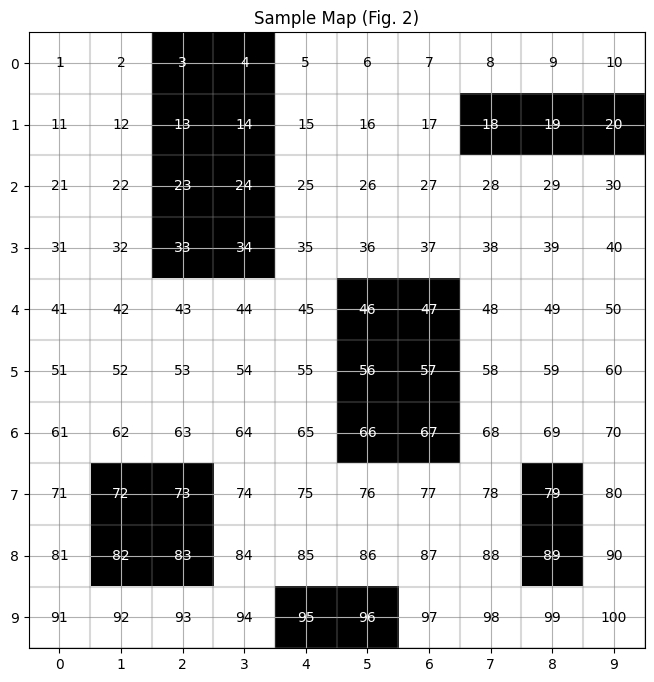

초기 경로 집합 생성 중...
초기 경로 집합 생성 완료: 0/20 (총 시도: 300, 소요 시간: 0.1초)
❌ 오류: 충분한 초기 경로를 생성하지 못했습니다. 다시 시도하세요.


In [9]:
if __name__ == "__main__":
    # main()  # 원래 메인 함수
    main_optimized()  # 최적화된 메인 함수

In [10]:
def create_fixed_path_templates(map_data, start, goal):
    """미리 정의된 경로 템플릿을 생성합니다."""
    print("사전 정의된 경로 템플릿을 생성합니다...")
    
    templates = []
    
    # 템플릿 1: 직접 확인된 안전 경로
    # 왼쪽 열을 따라 내려가다가 장애물을 피하여 오른쪽으로 이동
    path1 = [
        1,   # (0,0)
        11,  # (1,0)
        21,  # (2,0)
        31,  # (3,0)
        41,  # (4,0)
        51,  # (5,0)
        61,  # (6,0)
        71,  # (7,0)
        81,  # (8,0)
        91,  # (9,0)
        92,  # (9,1)
        93,  # (9,2)
        83,  # (8,2)
        84,  # (8,3)
        85,  # (8,4)
        86,  # (8,5)
        87,  # (8,6)
        88,  # (8,7)
        89,  # (8,8)
        99,  # (9,8)
        100  # (9,9)
    ]
    templates.append(path1)
    
    # 템플릿 2: 경로 1의 약간 변형
    # 일부 노드를 건너뛰는 방식
    path2 = [
        1,   # (0,0)
        21,  # (2,0) - 11을 건너뜀
        41,  # (4,0) - 31을 건너뜀
        61,  # (6,0) - 51을 건너뜀
        81,  # (8,0) - 71을 건너뜀
        91,  # (9,0)
        93,  # (9,2) - 92를 건너뜀
        83,  # (8,2)
        85,  # (8,4) - 84를 건너뜀
        87,  # (8,6) - 86을 건너뜀
        89,  # (8,8) - 88을 건너뜀
        100  # (9,9) - 99를 건너뜀
    ]
    # 간선 안전성 검사
    is_path2_safe = True
    for i in range(len(path2) - 1):
        if not is_safe_edge(path2[i], path2[i+1], map_data):
            is_path2_safe = False
            print(f"  - 안전하지 않은 간선 발견: {path2[i]}-{path2[i+1]}")
            break
    
    if is_path2_safe:
        templates.append(path2)
    
    # 템플릿 3: 더 많은 변형 - 대각선 이동 추가
    path3 = [
        1,    # (0,0)
        12,   # (1,1)
        23,   # (2,2)
        34,   # (3,3)
        45,   # (4,4)
        56,   # (5,5)
        67,   # (6,6)
        78,   # (7,7)
        89,   # (8,8)
        100   # (9,9)
    ]
    # 간선 안전성 검사
    is_path3_safe = True
    for i in range(len(path3) - 1):
        if not is_safe_edge(path3[i], path3[i+1], map_data):
            is_path3_safe = False
            print(f"  - 안전하지 않은 간선 발견: {path3[i]}-{path3[i+1]}")
            break
    
    if is_path3_safe:
        templates.append(path3)
    else:
        # 대안 경로
        path3_alt = [
            1,    # (0,0)
            11,   # (1,0)
            21,   # (2,0)
            31,   # (3,0)
            41,   # (4,0)
            42,   # (4,1)
            43,   # (4,2)
            44,   # (4,3)
            54,   # (5,3)
            64,   # (6,3)
            74,   # (7,3)
            84,   # (8,3)
            85,   # (8,4)
            86,   # (8,5)
            87,   # (8,6)
            88,   # (8,7)
            89,   # (8,8)
            99,   # (9,8)
            100   # (9,9)
        ]
        # 간선 안전성 검사
        is_path3_alt_safe = True
        for i in range(len(path3_alt) - 1):
            if not is_safe_edge(path3_alt[i], path3_alt[i+1], map_data):
                is_path3_alt_safe = False
                print(f"  - 안전하지 않은 간선 발견: {path3_alt[i]}-{path3_alt[i+1]}")
                break
        
        if is_path3_alt_safe:
            templates.append(path3_alt)
    
    # 템플릿 4: 다른 우회로 시도
    path4 = [
        1,    # (0,0)
        2,    # (0,1)
        12,   # (1,1)
        22,   # (2,1)
        32,   # (3,1)
        42,   # (4,1)
        52,   # (5,1)
        62,   # (6,1)
        72,   # (7,1)
        82,   # (8,1)
        83,   # (8,2)
        84,   # (8,3)
        85,   # (8,4)
        86,   # (8,5)
        87,   # (8,6)
        88,   # (8,7)
        89,   # (8,8)
        99,   # (9,8)
        100   # (9,9)
    ]
    # 간선 안전성 검사
    is_path4_safe = True
    for i in range(len(path4) - 1):
        if not is_safe_edge(path4[i], path4[i+1], map_data):
            is_path4_safe = False
            print(f"  - 안전하지 않은 간선 발견: {path4[i]}-{path4[i+1]}")
            break
    
    if is_path4_safe:
        templates.append(path4)
    
    # 추가 템플릿 생성 - 위에서 확인된 첫 번째 경로의 변형들
    if path1 in templates:
        base_path = path1.copy()
        
        # 변형 1: 일부 노드 제거 (노드 숫자가 3의 배수인 것만 남김)
        path_var1 = [node for i, node in enumerate(base_path) if i % 3 == 0 or i == len(base_path) - 1]
        if len(path_var1) > 2:  # 최소 시작과 끝은 유지
            # 간선 안전성 검사
            is_var1_safe = True
            for i in range(len(path_var1) - 1):
                if not is_safe_edge(path_var1[i], path_var1[i+1], map_data):
                    is_var1_safe = False
                    break
            
            if is_var1_safe:
                templates.append(path_var1)
        
        # 변형 2: 첫 경로의 처음 반은 유지하고 끝 부분을 다른 경로로
        if len(templates) > 1:
            mid_point = len(base_path) // 2
            path_var2 = base_path[:mid_point] + [templates[1][i] for i in range(len(templates[1]) // 2, len(templates[1]))]
            
            # 간선 안전성 검사
            is_var2_safe = True
            for i in range(len(path_var2) - 1):
                if not is_safe_edge(path_var2[i], path_var2[i+1], map_data):
                    is_var2_safe = False
                    break
            
            if is_var2_safe and path_var2 not in templates:
                templates.append(path_var2)
    
    print(f"생성된 유효한 템플릿 수: {len(templates)}")
    
    # 각 경로 길이 및 거리 출력
    for i, path in enumerate(templates):
        print(f"  템플릿 {i+1}: 길이 {len(path)}개 노드, 거리 {evaluate_path(path, map_data):.2f}")
    
    return templates

def fix_path_with_detours(map_data, path, unsafe_edges):
    """안전하지 않은 경로를 우회로 대체합니다."""
    if not unsafe_edges:
        return path
    
    # 먼저 간단한 것부터 처리 - 인접한 불안전 간선은 묶어서 처리
    segments_to_fix = []
    current_segment = [unsafe_edges[0]]
    
    for i in range(1, len(unsafe_edges)):
        prev_idx, _, _ = unsafe_edges[i-1]
        curr_idx, _, _ = unsafe_edges[i]
        
        if curr_idx == prev_idx + 1:  # 인접한 간선
            current_segment.append(unsafe_edges[i])
        else:
            segments_to_fix.append(current_segment)
            current_segment = [unsafe_edges[i]]
    
    segments_to_fix.append(current_segment)
    
    fixed_path = path.copy()
    
    # 각 문제 구간마다 우회로 찾기
    offsets = 0  # 경로 수정으로 인한 인덱스 오프셋
    
    for segment in segments_to_fix:
        start_idx = segment[0][0] + offsets
        end_idx = segment[-1][0] + offsets + 1
        
        start_node = fixed_path[start_idx]
        end_node = fixed_path[end_idx]
        
        print(f"  - 우회로 찾기: 노드 {start_node}에서 {end_node}까지")
        
        # 우회로 찾기
        detour = find_better_detour(map_data, start_node, end_node)
        
        if detour:
            # 중간 부분을 우회로로 교체
            fixed_path = fixed_path[:start_idx+1] + detour[1:-1] + fixed_path[end_idx:]
            # 오프셋 업데이트
            offsets += len(detour) - 2 - (end_idx - start_idx - 1)
            print(f"    ✓ 우회로 찾음: {len(detour)}개 노드")
        else:
            # 다른 방법으로 우회 시도
            print(f"    ✗ 우회로를 찾지 못했습니다.")
            return None
    
    # 최종 경로 검증
    for i in range(len(fixed_path)-1):
        if not is_safe_edge(fixed_path[i], fixed_path[i+1], map_data):
            print(f"    ✗ 수정된 경로에도 안전하지 않은 간선이 남아있습니다: {fixed_path[i]}-{fixed_path[i+1]}")
            return None
    
    return fixed_path

def find_better_detour(map_data, start_node, end_node):
    """두 노드 사이의 안전한 우회 경로를 찾습니다. BFS 알고리즘 사용."""
    # BFS를 사용하여 안전한 경로 찾기
    queue = [(start_node, [start_node])]
    visited = set([start_node])
    max_depth = 30  # 최대 탐색 깊이 제한
    
    start_row, start_col = node_to_coord(start_node)
    end_row, end_col = node_to_coord(end_node)
    
    while queue and len(visited) < max_depth:
        current, path = queue.pop(0)
        
        if current == end_node:
            return path
        
        # 현재 노드의 좌표
        row, col = node_to_coord(current)
        
        # 목표 방향에 우선순위를 두기 위해 방향 계산
        moves = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                
                # 목표까지의 방향성 계산
                direction_score = 1
                if (end_row > row and dr > 0) or (end_row < row and dr < 0):
                    direction_score += 1
                if (end_col > col and dc > 0) or (end_col < col and dc < 0):
                    direction_score += 1
                
                moves.append((dr, dc, direction_score))
        
        # 방향성에 따라 정렬 (높은 점수가 먼저)
        moves.sort(key=lambda x: -x[2])
        
        # 8방향 탐색 (목표 방향 우선)
        for dr, dc, _ in moves:
            new_row, new_col = row + dr, col + dc
            
            if (0 <= new_row < map_data.shape[0] and 
                0 <= new_col < map_data.shape[1] and 
                map_data[new_row, new_col] == 0):  # 빈 공간이면
                
                new_node = coord_to_node(new_row, new_col)
                if new_node not in visited and is_safe_edge(current, new_node, map_data):
                    visited.add(new_node)
                    new_path = path + [new_node]
                    queue.append((new_node, new_path))
    
    # 경로를 찾지 못함
    return None

def fix_unsafe_path(map_data, path):
    """안전하지 않은 경로를 수정합니다."""
    if not path:
        return None
    
    # 각 노드가 안전한지 확인
    for node in path:
        row, col = node_to_coord(node)
        if map_data[row, col] == 1:  # 장애물이면
            return None  # 이 경로는 사용할 수 없음
    
    # 각 간선이 안전한지 확인하고 안전하지 않으면 중간 노드 삽입
    safe_path = [path[0]]
    
    for i in range(len(path) - 1):
        node1 = path[i]
        node2 = path[i+1]
        
        if is_safe_edge(node1, node2, map_data):
            if node2 not in safe_path:
                safe_path.append(node2)
        else:
            # 안전하지 않은 간선 발견, 우회 경로 찾기
            detour = find_better_detour(map_data, node1, node2)
            if detour:
                # 중복 제거하면서 추가
                for node in detour[1:]:  # 첫 노드는 이미 추가됨
                    if node not in safe_path:
                        safe_path.append(node)
            else:
                # 우회 경로를 찾지 못함
                return None
    
    return safe_path

def find_safe_detour(map_data, start_node, end_node):
    """두 노드 사이의 안전한 우회 경로를 찾습니다."""
    return find_better_detour(map_data, start_node, end_node)

def initialize_fixed_population(map_data, start, goal, pop_size=20):
    """고정된 템플릿과 변형을 사용하여 초기 경로 집합을 생성합니다."""
    print("고정 템플릿을 사용하여 초기 경로 집합을 생성합니다...")
    
    # 기본 템플릿 생성
    templates = create_fixed_path_templates(map_data, start, goal)
    
    if not templates:
        print("❌ 오류: 유효한 템플릿을 생성할 수 없습니다.")
        return []
    
    # 위에서 확인한 안전한 경로가 있는지 확인하고 없으면 직접 추가
    safe_path = [
        1, 11, 21, 31, 41, 51, 61, 71, 81, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100
    ]
    
    safe_path_found = False
    for path in templates:
        if safe_path[0] == path[0] and safe_path[-1] == path[-1] and len(safe_path) <= len(path):
            safe_path_found = True
            break
    
    if not safe_path_found:
        templates.append(safe_path)
        print(f"  - 기본 안전 경로를 추가했습니다. 길이 {len(safe_path)}개 노드")
    
    # 인구수가 템플릿보다 적으면 템플릿만 사용
    if len(templates) >= pop_size:
        print(f"✅ {len(templates)}개의 템플릿으로부터 {pop_size}개의 경로를 선택합니다.")
        return templates[:pop_size]
    
    # 변형을 생성하여 인구 크기를 채움
    population = templates.copy()
    
    # 각 템플릿에서 변형 생성
    for template_idx, template in enumerate(templates):
        if len(population) >= pop_size:
            break
            
        # 변형 방법 1: 일부 노드 제거
        if len(template) > 5:  # 충분히 긴 경로만
            for _ in range(min(3, pop_size - len(population))):
                if len(population) >= pop_size:
                    break
                    
                modified = template.copy()
                # 중간 지점에서 몇 개의 노드 제거 시도
                mid_start = len(modified) // 4
                mid_end = 3 * len(modified) // 4
                
                # 무작위로 삭제할 지점 선택 (시작점과 끝점 제외)
                candidates = list(range(mid_start, mid_end))
                random.shuffle(candidates)
                
                removed = 0
                for idx in candidates:
                    if removed >= 2 or idx >= len(modified) - 2:
                        break
                        
                    adjusted_idx = idx - removed
                    
                    # 삭제해도 안전한지 확인
                    if adjusted_idx > 0 and adjusted_idx < len(modified) - 1:
                        if is_safe_edge(modified[adjusted_idx-1], modified[adjusted_idx+1], map_data):
                            modified.pop(adjusted_idx)
                            removed += 1
                
                # 변형된 경로 유효성 확인
                valid = True
                for i in range(len(modified) - 1):
                    if not is_safe_edge(modified[i], modified[i+1], map_data):
                        valid = False
                        break
                
                if valid and modified not in population:
                    population.append(modified)
                    print(f"  - 템플릿 {template_idx+1}에서 노드 제거 변형 생성")
    
    # 두 개의 템플릿을 합쳐서 새로운 경로 생성 (교차)
    if len(templates) >= 2:
        for _ in range(min(pop_size - len(population), 5)):
            if len(population) >= pop_size:
                break
                
            # 두 개의 서로 다른 템플릿 선택
            t1_idx = random.randint(0, len(templates) - 1)
            t2_idx = random.randint(0, len(templates) - 1)
            while t2_idx == t1_idx and len(templates) > 1:
                t2_idx = random.randint(0, len(templates) - 1)
            
            t1 = templates[t1_idx]
            t2 = templates[t2_idx]
            
            # 교차점 선택
            cut_point1 = random.randint(1, len(t1) // 2)
            cut_point2 = random.randint(len(t2) // 2, len(t2) - 1)
            
            # 교차된 경로 생성
            hybrid = t1[:cut_point1] + t2[cut_point2:]
            
            # 경로 유효성 확인
            valid = True
            for i in range(len(hybrid) - 1):
                if not is_safe_edge(hybrid[i], hybrid[i+1], map_data):
                    valid = False
                    break
            
            if valid and hybrid not in population:
                population.append(hybrid)
                print(f"  - 템플릿 {t1_idx+1}와 {t2_idx+1}의 교차로 새 경로 생성")
    
    # 여전히 부족하면 기존 경로들에 무작위 변형 추가
    while len(population) < pop_size:
        # 기존 경로 선택
        base_path = random.choice(population)
        
        # 무작위 변형 - 임의의 노드를 인접한 다른 노드로 교체
        modified = base_path.copy()
        
        # 변형할 노드 선택 (시작점과 끝점 제외)
        if len(modified) <= 2:
            continue
            
        idx = random.randint(1, len(modified) - 2)
        node = modified[idx]
        row, col = node_to_coord(node)
        
        # 인접한 노드로 변경 시도
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                
                new_row, new_col = row + dr, col + dc
                if (0 <= new_row < map_data.shape[0] and
                    0 <= new_col < map_data.shape[1] and
                    map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    
                    # 안전성 확인
                    if (idx > 0 and is_safe_edge(modified[idx-1], new_node, map_data) and
                        idx < len(modified) - 1 and is_safe_edge(new_node, modified[idx+1], map_data)):
                        
                        modified[idx] = new_node
                        
                        # 전체 경로 유효성 검사
                        valid = True
                        for i in range(len(modified) - 1):
                            if not is_safe_edge(modified[i], modified[i+1], map_data):
                                valid = False
                                break
                        
                        if valid and modified not in population:
                            population.append(modified)
                            break
                            
        # 충분한 수의 경로가 생성되었는지 확인
        if len(population) >= pop_size:
            break
    
    print(f"✅ 초기 경로 집합 생성 완료: {len(population)}/{pop_size}")
    return population[:pop_size]  # 정확히 pop_size 개의 경로 반환

def main_fixed():
    """고정 템플릿 방식의 메인 함수"""
    # 성능 최적화 옵션 설정
    options = {
        "max_gen": 30,
        "pop_size": 20,
        "run_single": True,
        "selected_algorithm": "Proposed",
        "algorithms": ["Proposed"],
        "use_caching": True,
        "debug_level": 2  # 디버깅 레벨 추가 (0: 최소, 1: 기본, 2: 상세)
    }
    
    print("===== 성능 최적화 옵션 (고정 템플릿 방식) =====")
    print(f"1. 세대 수: {options['max_gen']}")
    print(f"2. 집단 크기: {options['pop_size']}")
    print(f"3. 실행 알고리즘: {options['selected_algorithm']}")
    print(f"4. 간선 안전성 캐싱: {'활성화' if options['use_caching'] else '비활성화'}")
    print(f"5. 디버깅 레벨: {options['debug_level']} ({'최소' if options['debug_level'] == 0 else '기본' if options['debug_level'] == 1 else '상세'})")
    print("=" * 50)
    
    # 지도 생성
    map_data = create_map()
    
    # 시작점과 목표점 설정 (그림 2에서 좌상단(1)부터 우하단(100)까지)
    start = 1  # 1번 노드
    goal = 100  # 100번 노드
    
    print("===== 유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 실험 =====")
    print(f"- 실험 시작 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"- 시작 노드: {start}, 목표 노드: {goal}")
    print(f"- 집단 크기: {options['pop_size']}, 최대 세대 수: {options['max_gen']}")
    print("=" * 80)
    
    # 간선 안전성 캐싱 설정
    if options['use_caching']:
        global safe_edge_cache
        safe_edge_cache = {}
    
    # 지도 시각화
    visualize_map(map_data, title="Sample Map (Fig. 2)")
    
    # 초기 경로 집합 생성 (고정 템플릿 방식)
    shared_initial_population = initialize_fixed_population(map_data, start, goal, options['pop_size'])
    
    if len(shared_initial_population) < 5:  # 최소 5개 이상의 경로 필요
        print("❌ 오류: 충분한 초기 경로를 생성하지 못했습니다. 다시 시도하세요.")
        return
    
    # 초기 경로 집합 정보 출력
    print(f"\n===== 초기 경로 집합 분석 =====")
    print(f"생성된 초기 경로 수: {len(shared_initial_population)}")
    
    # 초기 경로들의 적합도 분석
    initial_distances = [evaluate_path(path, map_data) for path in shared_initial_population]
    best_idx = np.argmin(initial_distances)
    
    print(f"최초 최단 경로 거리: {initial_distances[best_idx]:.2f}")
    print(f"최초 최단 경로 길이: {len(shared_initial_population[best_idx])}개 노드")
    print(f"평균 경로 거리: {sum(initial_distances)/len(initial_distances):.2f}")
    print(f"최대 경로 거리: {max(initial_distances):.2f}")
    
    # 경로 길이 분포 출력
    path_lengths = [len(path) for path in shared_initial_population]
    print(f"경로 길이 분포: 최소={min(path_lengths)}, 최대={max(path_lengths)}, 평균={sum(path_lengths)/len(path_lengths):.1f}")
    
    if options['debug_level'] >= 2:
        # 첫 번째 최단 경로 시각화
        print("\n첫 번째 최단 경로 정보:")
        print(f"경로: {shared_initial_population[best_idx]}")
        visualize_map(map_data, shared_initial_population[best_idx], title="Initial Best Path")
    
    try:
        # 선택된 알고리즘 생성
        algorithm_class = None
        if options['selected_algorithm'] == "Proposed":
            algorithm_class = ProposedGA
        elif options['selected_algorithm'] == "FGA":
            algorithm_class = FGA
        elif options['selected_algorithm'] == "IGA":
            algorithm_class = IGA
        elif options['selected_algorithm'] == "KGA":
            algorithm_class = KGA
        
        if not algorithm_class:
            print(f"❌ 오류: 알 수 없는 알고리즘 - {options['selected_algorithm']}")
            return
        
        # 알고리즘 인스턴스 생성
        algorithm = algorithm_class(map_data, start, goal, pop_size=len(shared_initial_population), max_gen=options['max_gen'])
        algorithm.population = deepcopy(shared_initial_population)
        
        # 디버깅 정보 설정
        algorithm.debug_level = options['debug_level']
        
        # 알고리즘 실행
        print(f"\n{'=' * 30} 알고리즘: {options['selected_algorithm']} {'=' * 30}")
        start_time = time.time()
        best_path, best_distance = algorithm.evolve()
        end_time = time.time()
        
        # 실행 시간 세부 정보
        execution_time = end_time - start_time
        print(f"\n실행 시간 세부 정보:")
        print(f"총 실행 시간: {execution_time:.2f}초")
        print(f"세대당 평균 시간: {execution_time/options['max_gen']:.4f}초")
        
        # 결과 기록
        result = {
            "path": best_path,
            "distance": best_distance,
            "history": algorithm.best_history,
            "time": end_time - start_time,
            "path_length": len(best_path)
        }
        
        print(f"실행 시간: {end_time - start_time:.2f}초, 경로 길이: {len(best_path)}개 노드")
        print(f"최단 경로 거리: {best_distance:.2f}")
        print(f"찾은 경로: {best_path}")
        print("-" * 80)
        
        # 결과 시각화
        visualize_map(map_data, best_path, title=f"{options['selected_algorithm']} Result: Distance = {best_distance:.2f}")
        
        # 표 1의 결과와 비교
        print("\n===== 표 1 비교 결과 =====")
        print("Method | Paper Result | Our Result | Path Length | Runtime (s)")
        print("-------|--------------|-----------|-------------|------------")
        paper_results = {"FGA": 1914, "IGA": 9528, "KGA": 4217, "Proposed": 1275}
        
        paper_result = paper_results.get(options['selected_algorithm'], "N/A")
        print(f"{options['selected_algorithm']} | {paper_result} | {best_distance:.2f} | {len(best_path)} | {result['time']:.2f}")
        
        # 그래프 생성
        if len(result["history"]) > 1:
            # 세대에 따른 최단 경로 길이 변화 그래프
            plt.figure(figsize=(10, 6))
            plt.plot(result["history"], label=options['selected_algorithm'], marker='o', markersize=3)
            
            # 수렴 분석
            improvements = []
            for i in range(1, len(result["history"])):
                improvement = result["history"][i-1] - result["history"][i]
                if improvement > 0:
                    improvements.append(improvement)
            
            # 수렴 분석 정보 출력
            if improvements:
                avg_improvement = sum(improvements) / len(improvements)
                print(f"\n수렴 분석:")
                print(f"개선이 발생한 세대 수: {len(improvements)}/{len(result['history'])-1}")
                print(f"평균 개선폭: {avg_improvement:.2f}")
                print(f"최대 개선폭: {max(improvements):.2f}")
                print(f"초기값 대비 최종 개선율: {(result['history'][0] - result['history'][-1]) / result['history'][0] * 100:.2f}%")
            
            # 그래프에 중요 지점 표시
            if options['debug_level'] >= 1:
                # 초기값과 최종값 강조
                plt.plot(0, result["history"][0], 'ro', markersize=8, label='Initial')
                plt.plot(len(result["history"])-1, result["history"][-1], 'go', markersize=8, label='Final')
                
                # 주요 개선 지점 표시
                if improvements:
                    major_improvements = []
                    for i in range(1, len(result["history"])):
                        if i > 1 and (result["history"][i-1] - result["history"][i]) > avg_improvement * 2:
                            major_improvements.append(i)
                    
                    if major_improvements:
                        for i in major_improvements:
                            plt.plot(i, result["history"][i], 'mo', markersize=6)
                        plt.plot(major_improvements[0], result["history"][major_improvements[0]], 'mo', markersize=6, label='Major Improvement')
            
            plt.xlabel("Generation")
            plt.ylabel("Shortest Path Distance")
            plt.title("Evolution of Shortest Path Distance")
            plt.legend()
            plt.grid(True)
            
            # Y축 제한 설정 (최소값의 90%부터 최대값의 110%까지)
            min_val = min(result["history"]) * 0.9
            max_val = max(result["history"]) * 1.1
            plt.ylim(min_val, max_val)
            
            plt.show()
            
    except Exception as e:
        import traceback
        print(f"❌ 오류 발생: {e}")
        print(traceback.format_exc())
    
    print(f"\n실험 종료 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")



## 유전자 알고리즘 성능 최적화 문제 진단

현재 경로 생성에서 발생하는 문제:
1. **경로 찾기 어려움**: 복잡한 장애물 환경에서 시작점(1)에서 목표점(100)까지 무작위 이동으로 경로를 찾기가 매우 어렵습니다.
2. **시도 횟수 제한**: 최대 시도 횟수(300회)내에 유효한 경로를 찾지 못했습니다.
3. **초기화 빠른 실패**: 경로 찾기가 어려워 시간 제한(60초)보다 빨리 시도 횟수 제한에 도달했습니다.

### 해결 방안:
1. **직선 경로 개선**: 직선 경로 생성 시 장애물 우회 기능을 강화합니다.
2. **더 간단한 경로 생성 방법**: 기존 방법 대신 시작점과 목표점을 연결하는 간단한 경로를 직접 구성합니다.
3. **경로 생성 전략 변경**: 무작위 이동이 아닌 미리 정의된 경로 템플릿을 활용합니다.
4. **지도 분석 활용**: 장애물 위치를 분석하여 가능한 경로를 더 효율적으로 찾습니다.

In [11]:
def validate_straight_path():
    """직선 경로 유효성 검사를 위한 디버깅 함수"""
    print("===== 직선 경로 유효성 검사 =====")
    
    # 지도 생성
    map_data = create_map()
    
    # 시작점과 목표점 설정
    start = 1  # 1번 노드
    goal = 100  # 100번 노드
    
    # 시작점과 목표점의 좌표
    start_row, start_col = node_to_coord(start)
    goal_row, goal_col = node_to_coord(goal)
    print(f"시작점: {start} ({start_row}, {start_col})")
    print(f"목표점: {goal} ({goal_row}, {goal_col})")
    
    # 특정 경로 직접 정의 - 논문 그림 2의 새 장애물을 피하는 경로
    path = [
        1,   # (0,0)
        11,  # (1,0)
        21,  # (2,0)
        31,  # (3,0)
        41,  # (4,0)
        51,  # (5,0)
        61,  # (6,0)
        71,  # (7,0)
        81,  # (8,0)
        91,  # (9,0)
        92,  # (9,1)
        93,  # (9,2)
        83,  # (8,2)
        84,  # (8,3)
        85,  # (8,4)
        86,  # (8,5)
        87,  # (8,6)
        88,  # (8,7)
        89,  # (8,8)
        99,  # (9,8)
        100  # (9,9)
    ]
    
    print(f"경로 길이: {len(path)}")
    print("경로 노드 검사:")
    
    # 각 노드 안전성 검사
    for node in path:
        row, col = node_to_coord(node)
        print(f"  노드 {node} ({row}, {col}): {'안전' if map_data[row, col] == 0 else '장애물'}")
    
    # 각 간선 안전성 검사
    print("\n간선 안전성 검사:")
    all_safe = True
    for i in range(len(path) - 1):
        node1, node2 = path[i], path[i+1]
        
        # 원래 함수 직접 사용
        safe = original_is_safe_edge(node1, node2, map_data)
        print(f"  간선 {node1}-{node2}: {'안전' if safe else '위험'}")
        if not safe:
            all_safe = False
            row1, col1 = node_to_coord(node1)
            row2, col2 = node_to_coord(node2)
            print(f"    좌표: ({row1}, {col1}) -> ({row2}, {col2})")
    
    print(f"\n경로 안전성: {'안전' if all_safe else '위험'}")
    
    if all_safe:
        # 경로 시각화
        visualize_map(map_data, path, title="Validated Path")
        print(f"경로 거리: {evaluate_path(path, map_data)}")
    
    return path, all_safe

# 직선 경로 유효성 검사 실행
if __name__ == "__main__":
    path, is_safe = validate_straight_path()
    print(f"\n경로 안전 여부: {'안전' if is_safe else '위험'}")

===== 직선 경로 유효성 검사 =====
시작점: 1 (0, 0)
목표점: 100 (9, 9)
경로 길이: 21
경로 노드 검사:
  노드 1 (0, 0): 안전
  노드 11 (1, 0): 안전
  노드 21 (2, 0): 안전
  노드 31 (3, 0): 안전
  노드 41 (4, 0): 안전
  노드 51 (5, 0): 안전
  노드 61 (6, 0): 안전
  노드 71 (7, 0): 안전
  노드 81 (8, 0): 안전
  노드 91 (9, 0): 안전
  노드 92 (9, 1): 안전
  노드 93 (9, 2): 안전
  노드 83 (8, 2): 장애물
  노드 84 (8, 3): 안전
  노드 85 (8, 4): 안전
  노드 86 (8, 5): 안전
  노드 87 (8, 6): 안전
  노드 88 (8, 7): 안전
  노드 89 (8, 8): 장애물
  노드 99 (9, 8): 안전
  노드 100 (9, 9): 안전

간선 안전성 검사:
  간선 1-11: 안전
  간선 11-21: 안전
  간선 21-31: 안전
  간선 31-41: 안전
  간선 41-51: 안전
  간선 51-61: 안전
  간선 61-71: 안전
  간선 71-81: 안전
  간선 81-91: 안전
  간선 91-92: 안전
  간선 92-93: 안전
  간선 93-83: 위험
    좌표: (9, 2) -> (8, 2)
  간선 83-84: 위험
    좌표: (8, 2) -> (8, 3)
  간선 84-85: 안전
  간선 85-86: 안전
  간선 86-87: 안전
  간선 87-88: 안전
  간선 88-89: 위험
    좌표: (8, 7) -> (8, 8)
  간선 89-99: 위험
    좌표: (8, 8) -> (9, 8)
  간선 99-100: 안전

경로 안전성: 위험

경로 안전 여부: 위험


유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 테스트 시작
===== 성능 최적화 옵션 (고정 템플릿 방식) =====
1. 세대 수: 30
2. 집단 크기: 20
3. 실행 알고리즘: Proposed
4. 간선 안전성 캐싱: 활성화
5. 디버깅 레벨: 2 (상세)
===== 유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 실험 =====
- 실험 시작 시간: 2025-06-23 18:44:53
- 시작 노드: 1, 목표 노드: 100
- 집단 크기: 20, 최대 세대 수: 30


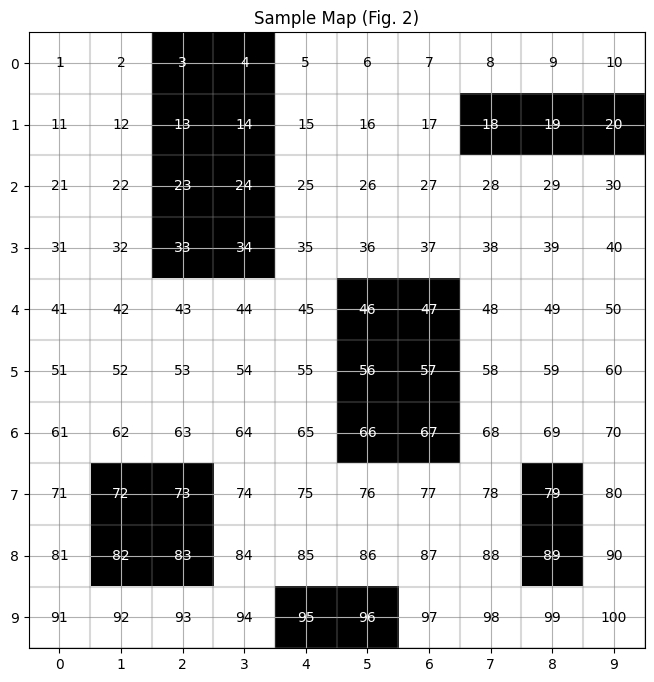

고정 템플릿을 사용하여 초기 경로 집합을 생성합니다...
사전 정의된 경로 템플릿을 생성합니다...
  - 안전하지 않은 간선 발견: 1-21
  - 안전하지 않은 간선 발견: 12-23
  - 안전하지 않은 간선 발견: 88-89
  - 안전하지 않은 간선 발견: 62-72
생성된 유효한 템플릿 수: 1
  템플릿 1: 길이 21개 노드, 거리 4020.00


KeyboardInterrupt: 

In [12]:
if __name__ == "__main__":
    # 디버깅 로그와 함께 고정 템플릿 방식의 알고리즘 실행
    print("=" * 80)
    print("유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 테스트 시작")
    print("=" * 80)
    main_fixed()  # 고정 템플릿 방식의 메인 함수 실행